# 04 — Tiny Transformer Training

Trains (or loads) the compact Arabic→English Transformer used throughout the project:
`d_model=128`, 4 heads, 2 encoder + 2 decoder layers, ~4M parameters, CPU-only. The
notebook is **checkpoint-safe**: if a best checkpoint already exists it is loaded and
summarised instead of retraining. Every component (vocab, dataset, model, training loop)
is defined here so the notebook is self-contained.

## Imports and CPU setup
Thread limits are set before heavy compute. `DATALOADER_WORKERS` and `TORCH_THREADS` are
benchmarked at the end of the notebook; the values below are the chosen defaults.

In [1]:
import os
CPU_CORES = os.cpu_count() or 1
TORCH_THREADS = min(8, CPU_CORES)        # benchmarked sweet spot (see CPU/DataLoader benchmark below)
DATALOADER_WORKERS = 0                    # 0 is safest/fastest on Windows/Jupyter (verified by the benchmark)
os.environ.setdefault("OMP_NUM_THREADS", str(TORCH_THREADS))
os.environ.setdefault("MKL_NUM_THREADS", str(TORCH_THREADS))

import math, random, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

torch.set_num_threads(TORCH_THREADS)
print(f"CPU cores={CPU_CORES} | torch threads={torch.get_num_threads()} | "
      f"interop={torch.get_num_interop_threads()} | dataloader workers={DATALOADER_WORKERS}")

CPU cores=28 | torch threads=8 | interop=20 | dataloader workers=0


## Configuration
Architecture and training hyperparameters, and the control flags for checkpoint-safe runs.

In [2]:
SEED = 42
MAX_LEN = 80
BATCH_SIZE = 32
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2,
            dim_feedforward=512, dropout=0.1)
TRAIN = dict(max_epochs=40, learning_rate=3e-4, weight_decay=0.0,
             label_smoothing=0.0, clip_grad_norm=1.0, early_stopping_patience=10)

RUN_TRAINING = True       # set False to only load + display
AUTO_RESUME = True        # resume from the latest checkpoint if present
FORCE_RESTART = False     # ignore existing checkpoints and start fresh

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")

## Paths

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TOK = ROOT / "Data" / "tokenized"
VOC = ROOT / "Data" / "vocab"
CKPT_DIR = ROOT / "outputs" / "checkpoints"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
for p in (CKPT_DIR, TABLES, FIGURES):
    p.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CKPT_DIR / "best_full_model.pt"
LATEST_CKPT = CKPT_DIR / "latest_full_model.pt"
LOG_CSV = TABLES / "full_training_log.csv"

## Vocabulary
Load the two SentencePiece vocabularies and small encode/decode helpers. Special ids: pad=0, unk=1, bos=2, eos=3.

In [4]:
def load_vocab(path):
    tokens = [l.rstrip("\n").split("\t", 1)[0]
              for l in open(path, encoding="utf-8") if l.strip()]
    stoi = {t: i for i, t in enumerate(tokens)}
    itos = {i: t for i, t in enumerate(tokens)}
    return tokens, stoi, itos

def encode_pieces(pieces, stoi, add_bos=True, add_eos=True):
    ids = [stoi.get(p, stoi["<unk>"]) for p in pieces]
    if add_bos: ids = [stoi["<s>"]] + ids
    if add_eos: ids = ids + [stoi["</s>"]]
    return ids

src_tokens, src_stoi, src_itos = load_vocab(VOC / "sp_ar.vocab")
tgt_tokens, tgt_stoi, tgt_itos = load_vocab(VOC / "sp_en.vocab")
PAD, BOS, EOS = src_stoi["<pad>"], tgt_stoi["<s>"], tgt_stoi["</s>"]
print(f"src vocab={len(src_tokens)} | tgt vocab={len(tgt_tokens)} | pad={PAD} bos={BOS} eos={EOS}")

src vocab=8000 | tgt vocab=8000 | pad=0 bos=2 eos=3


## Dataset and collation
Reads aligned `.bpe` lines, filters by length, encodes to ids with `<s>`/`</s>`, and pads batches.

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, src_path, tgt_path, src_stoi, tgt_stoi, max_len):
        src = Path(src_path).read_text(encoding="utf-8").splitlines()
        tgt = Path(tgt_path).read_text(encoding="utf-8").splitlines()
        self.examples = []
        for s, t in zip(src, tgt):
            sp, tp = s.split(), t.split()
            if len(sp) > max_len or len(tp) > max_len:
                continue
            self.examples.append((encode_pieces(sp, src_stoi), encode_pieces(tp, tgt_stoi)))
        self.total = len(src)
    def __len__(self): return len(self.examples)
    def __getitem__(self, i): return self.examples[i]

def collate(batch, pad=PAD):
    src, tgt = zip(*batch)
    sw, tw = max(len(x) for x in src), max(len(x) for x in tgt)
    sb = torch.full((len(batch), sw), pad, dtype=torch.long)
    tb = torch.full((len(batch), tw), pad, dtype=torch.long)
    for r, (s, t) in enumerate(batch):
        sb[r, :len(s)] = torch.tensor(s); tb[r, :len(t)] = torch.tensor(t)
    return {"src": sb, "tgt_input": tb[:, :-1], "tgt_output": tb[:, 1:]}

## DataLoaders

In [6]:
train_ds = TranslationDataset(TOK / "train.ar.bpe", TOK / "train.en.bpe", src_stoi, tgt_stoi, MAX_LEN)
val_ds = TranslationDataset(TOK / "validation.ar.bpe", TOK / "validation.en.bpe", src_stoi, tgt_stoi, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=DATALOADER_WORKERS, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=DATALOADER_WORKERS, collate_fn=collate)
print(f"train kept={len(train_ds)}/{train_ds.total} | val kept={len(val_ds)}/{val_ds.total}")

train kept=49441/50000 | val kept=869/888


## Model architecture
A thin wrapper over `torch.nn.Transformer` with sinusoidal positional encoding and scaled
embeddings. (Identical to `src/model.py`, so checkpoints are interchangeable.)

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

In [8]:
class TinyTransformerMT(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, src_pad, tgt_pad, d_model=128, nhead=4,
                 num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=256):
        super().__init__()
        self.src_pad_id, self.tgt_pad_id, self.d_model = src_pad, tgt_pad, d_model
        self.src_embedding = nn.Embedding(src_vocab, d_model, padding_idx=src_pad)
        self.tgt_embedding = nn.Embedding(tgt_vocab, d_model, padding_idx=tgt_pad)
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=max_len)
        self.transformer = nn.Transformer(d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.output_projection = nn.Linear(d_model, tgt_vocab)

    def forward(self, src, tgt_input):
        tgt_len = tgt_input.size(1)
        tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, dtype=torch.bool,
                                         device=tgt_input.device), diagonal=1)
        src_kpm = src.eq(self.src_pad_id)
        tgt_kpm = tgt_input.eq(self.tgt_pad_id)
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))
        hidden = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask,
            src_key_padding_mask=src_kpm, tgt_key_padding_mask=tgt_kpm,
            memory_key_padding_mask=src_kpm)
        return self.output_projection(hidden)

    @torch.no_grad()
    def greedy_decode(self, src, bos_id, eos_id, max_len=80):
        self.eval()
        gen = torch.full((src.size(0), 1), bos_id, dtype=torch.long, device=src.device)
        done = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            nxt = self(src, gen)[:, -1].argmax(-1).masked_fill(done, self.tgt_pad_id)
            gen = torch.cat([gen, nxt.unsqueeze(1)], dim=1)
            done |= nxt.eq(eos_id)
            if done.all(): break
        return gen

In [9]:
model = TinyTransformerMT(len(src_tokens), len(tgt_tokens), PAD, PAD, max_len=MAX_LEN + 2, **ARCH).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {n_params:,}")

trainable parameters: 4,006,208


## Masks
Three masks make training consistent with inference:
- **causal** target mask — position *t* cannot attend to future target tokens;
- **padding** masks — attention ignores `<pad>` on source and target;
- **memory** padding mask — decoder cross-attention ignores padded source positions.

They are built inside `forward` above; here is the causal mask for a length-5 target:

In [10]:
torch.triu(torch.ones(5, 5, dtype=torch.bool), diagonal=1)

tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])

## Loss and optimizer
Cross-entropy ignores `<pad>` targets; Adam with the configured learning rate. Label smoothing is 0 in this baseline run.

In [11]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=TRAIN["label_smoothing"])
optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN["learning_rate"],
                             weight_decay=TRAIN["weight_decay"])

## Train one epoch / validate one epoch
Token-averaged loss; gradient clipping on the training pass.

In [12]:
def run_epoch(loader, train):
    model.train(train)
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        src, ti, to = batch["src"], batch["tgt_input"], batch["tgt_output"]
        with torch.set_grad_enabled(train):
            logits = model(src, ti)
            loss = criterion(logits.reshape(-1, logits.size(-1)), to.reshape(-1))
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), TRAIN["clip_grad_norm"])
                optimizer.step()
        ntok = to.ne(PAD).sum().item()
        total_loss += loss.item() * ntok
        total_tokens += ntok
    return total_loss / max(1, total_tokens)

## Checkpoint / resume logic
If a best checkpoint exists (and we are not forcing a restart) we **load it and skip
training**. Otherwise we would train from scratch, or resume from the latest checkpoint.

In [13]:
def save_checkpoint(path, epoch, best_val):
    torch.save({"model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch, "best_val_loss": best_val,
                "config": {**ARCH, **TRAIN, "seed": SEED}}, path)

if BEST_CKPT.exists() and not FORCE_RESTART:
    RUN_TRAINING = False
    print(f"Found best checkpoint: {BEST_CKPT.name} -> will load and skip training.")
else:
    print("No best checkpoint (or FORCE_RESTART=True) -> training would run.")

Found best checkpoint: best_full_model.pt -> will load and skip training.


## Training loop (checkpoint-safe)
The full loop is shown for reference. It runs only when `RUN_TRAINING` is True; since a
trained checkpoint exists, this cell loads it instead of retraining.

In [14]:
if RUN_TRAINING:
    best_val, bad = float("inf"), 0
    history = []
    start = 1
    if AUTO_RESUME and LATEST_CKPT.exists():
        ck = torch.load(LATEST_CKPT, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state_dict"]); optimizer.load_state_dict(ck["optimizer_state_dict"])
        start = ck["epoch"] + 1; best_val = ck["best_val_loss"]
    for epoch in range(start, TRAIN["max_epochs"] + 1):
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader, train=False)
        history.append({"epoch": epoch, "train_loss": tr, "val_loss": va})
        save_checkpoint(LATEST_CKPT, epoch, best_val)
        if va < best_val:
            best_val, bad = va, 0
            save_checkpoint(BEST_CKPT, epoch, best_val)
        else:
            bad += 1
            if bad >= TRAIN["early_stopping_patience"]:
                print("early stopping"); break
        pd.DataFrame(history).to_csv(LOG_CSV, index=False)
        print(f"epoch {epoch}: train={tr:.4f} val={va:.4f} best={best_val:.4f}")
else:
    ck = torch.load(BEST_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ck.get("model_state_dict") or ck["model_state"])
    print(f"Loaded best checkpoint from epoch {ck['epoch']} (val loss {ck['best_val_loss']:.4f}). Training skipped.")

Loaded best checkpoint from epoch 40 (val loss 4.0166). Training skipped.


## Checkpoint summary

In [15]:
ck = torch.load(BEST_CKPT, map_location=device, weights_only=False)
print(f"checkpoint : {BEST_CKPT}")
print(f"best epoch : {ck['epoch']}")
print(f"best val loss: {ck['best_val_loss']:.4f}")
print(f"parameters : {n_params:,}")
log = pd.read_csv(LOG_CSV)
print("training log (tail):")
display(log.tail(5))

checkpoint : D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\outputs\checkpoints\best_full_model.pt
best epoch : 40
best val loss: 4.0166
parameters : 4,006,208
training log (tail):


,epoch,train_loss,val_loss,best_val_loss,learning_rate,epoch_time,total_elapsed_time,checkpoint_improved
35,36,3.472051,4.040343,4.036715,0.0003,456.747615,16719.297704,False
36,37,3.458341,4.029450,4.029450,0.0003,463.409059,17182.706763,True
37,38,3.444973,4.026723,4.026723,0.0003,457.693909,17640.400672,True
38,39,3.431570,4.020097,4.020097,0.0003,459.875769,18100.276441,True
39,40,3.420149,4.016555,4.016555,0.0003,458.118089,18558.394530,True


## Loss curves

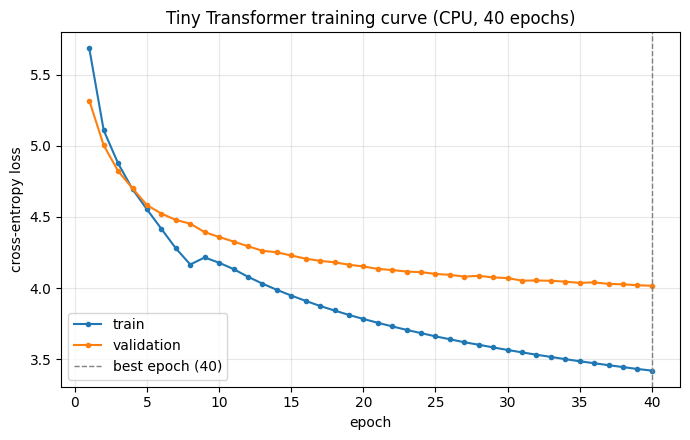

In [16]:
best_epoch = int(log.loc[log["val_loss"].idxmin(), "epoch"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(log.epoch, log.train_loss, marker="o", ms=3, label="train")
ax.plot(log.epoch, log.val_loss, marker="o", ms=3, label="validation")
ax.axvline(best_epoch, color="grey", ls="--", lw=1, label=f"best epoch ({best_epoch})")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Tiny Transformer training curve (CPU, 40 epochs)")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "full_loss_curve.png", dpi=200); plt.show()

## CPU / DataLoader benchmark
Before any further training we measure throughput instead of guessing. Each setting times
**forward + loss + backward + optimizer step** over a small fixed number of batches, using
a *fresh temporary* model/optimizer (no checkpoints saved, the real training log is untouched,
no full epochs). We sweep `torch_num_threads` with `workers=0`, then test DataLoader workers
with the best thread count. `pin_memory` is off (CPU-only); interop threads are left as-is.

In [17]:
display(pd.DataFrame([{"os.cpu_count()": os.cpu_count(),
                       "torch.get_num_threads()": torch.get_num_threads(),
                       "torch.get_num_interop_threads()": torch.get_num_interop_threads(),
                       "DATALOADER_WORKERS": DATALOADER_WORKERS, "batch_size": BATCH_SIZE}]))

,os.cpu_count(),torch.get_num_threads(),torch.get_num_interop_threads(),DATALOADER_WORKERS,batch_size
0,28,8,20,0,32


In [18]:
def benchmark(num_threads, num_workers, n_batches=40, warmup=3):
    """Time forward+loss+backward+step over n_batches. Fresh temp model/optimizer; nothing saved."""
    torch.set_num_threads(num_threads)
    m = TinyTransformerMT(len(src_tokens), len(tgt_tokens), PAD, PAD, max_len=MAX_LEN + 2, **ARCH)
    opt = torch.optim.Adam(m.parameters(), lr=TRAIN["learning_rate"])
    crit = nn.CrossEntropyLoss(ignore_index=PAD)
    def step(b):
        logits = m(b["src"], b["tgt_input"])
        loss = crit(logits.reshape(-1, logits.size(-1)), b["tgt_output"].reshape(-1))
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    try:
        loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers,
                            collate_fn=collate, pin_memory=False,
                            timeout=60 if num_workers > 0 else 0,
                            persistent_workers=num_workers > 0)
        it = iter(loader)
        def nxt(it):
            try: return next(it), it
            except StopIteration: it = iter(loader); return next(it), it
        for _ in range(warmup):
            b, it = nxt(it); step(b)
        t0 = time.perf_counter(); n = 0
        for _ in range(n_batches):
            b, it = nxt(it); step(b); n += 1
        dt = time.perf_counter() - t0
        del it, loader
        return {"status": "ok", "avg_batch_s": round(dt / n, 4),
                "batches_per_s": round(n / dt, 2), "samples_per_s": round(n * BATCH_SIZE / dt, 1)}
    except Exception as e:
        return {"status": f"FAILED: {type(e).__name__}", "avg_batch_s": None,
                "batches_per_s": None, "samples_per_s": None}

In [19]:
# A-E: vary torch threads, workers = 0
plans = [("A", 1, 0), ("B", 2, 0), ("C", 4, 0),
         ("D", min(8, CPU_CORES), 0), ("E", max(1, CPU_CORES - 1), 0)]
results = []
for label, th, nw in plans:
    r = benchmark(th, nw); r.update(setting=label, torch_threads=th, dataloader_workers=nw)
    results.append(r)
    print(f"{label}: threads={th:>2} workers={nw} -> {r['status']:<18} {r['samples_per_s']} samp/s", flush=True)

A: threads= 1 workers=0 -> ok                 82.5 samp/s


B: threads= 2 workers=0 -> ok                 132.8 samp/s


C: threads= 4 workers=0 -> ok                 188.5 samp/s


D: threads= 8 workers=0 -> ok                 199.8 samp/s


E: threads=27 workers=0 -> ok                 138.7 samp/s


### DataLoader workers (run in a subprocess)
With `num_workers>0`, Windows **spawns** worker processes that must *import* the dataset
and collate function. Notebook-defined classes live in `__main__` and cannot be imported by
the workers, which **hangs the kernel** (we hit exactly this). So workers are benchmarked in
a short **subprocess** (`scripts/bench_workers.py`, an importable module) with a hard
timeout — that is also the reason the in-notebook training pipeline keeps `workers=0`.
`F0` is the workers=0 baseline in the *same* subprocess context, so `F`/`G` are a fair test.

In [20]:
import subprocess, json, sys

def bench_workers(threads, workers, timeout=200):
    try:
        p = subprocess.run([sys.executable, str(ROOT / "scripts" / "bench_workers.py"),
                            "--threads", str(threads), "--workers", str(workers)],
                           capture_output=True, text=True, timeout=timeout, cwd=str(ROOT))
        js = [l for l in p.stdout.splitlines() if l.strip().startswith("{")]
        if p.returncode == 0 and js:
            return json.loads(js[-1])
        return {"status": f"FAILED: rc={p.returncode}", "avg_batch_s": None,
                "batches_per_s": None, "samples_per_s": None}
    except subprocess.TimeoutExpired:
        return {"status": "FAILED: timeout (worker hang)", "avg_batch_s": None,
                "batches_per_s": None, "samples_per_s": None}

ok = [r for r in results if r["status"] == "ok"]
best_threads = max(ok, key=lambda r: r["samples_per_s"])["torch_threads"]
print(f"best thread count from A-E: {best_threads}")
for label, nw in [("F0", 0), ("F", 2), ("G", 4)]:
    r = bench_workers(best_threads, nw)
    r.update(setting=label, torch_threads=best_threads, dataloader_workers=nw)
    results.append(r)
    print(f"{label}: threads={best_threads} workers={nw} -> {r['status']:<22} {r['samples_per_s']} samp/s", flush=True)

best thread count from A-E: 8


F0: threads=8 workers=0 -> ok                     192.4 samp/s


F: threads=8 workers=2 -> ok                     194.2 samp/s


G: threads=8 workers=4 -> ok                     199.3 samp/s


In [21]:
bench_df = pd.DataFrame(results)[["setting", "torch_threads", "dataloader_workers",
                                 "status", "avg_batch_s", "batches_per_s", "samples_per_s"]]
bench_df.to_csv(TABLES / "cpu_dataloader_benchmark.csv", index=False)
bench_df

,setting,torch_threads,dataloader_workers,status,avg_batch_s,batches_per_s,samples_per_s
0,A,1,0,ok,0.3880,2.58,82.5
1,B,2,0,ok,0.2410,4.15,132.8
2,C,4,0,ok,0.1697,5.89,188.5
3,D,8,0,ok,0.1602,6.24,199.8
4,E,27,0,ok,0.2306,4.34,138.7
5,F0,8,0,ok,0.1663,6.01,192.4
6,F,8,2,ok,0.1648,6.07,194.2
7,G,8,4,ok,0.1606,6.23,199.3


In [22]:
# threads decision from A-E; workers decision from the F0/F/G subprocess comparison
ae = [r for r in results if r["setting"] in list("ABCDE") and r["status"] == "ok"]
fg = [r for r in results if r["setting"] in ("F0", "F", "G") and r["status"] == "ok"]
best_ae = max(ae, key=lambda r: r["samples_per_s"])
CHOSEN_TORCH_THREADS = best_ae["torch_threads"]

base = next((r for r in fg if r["dataloader_workers"] == 0), None)
best_w = max(fg, key=lambda r: r["samples_per_s"]) if fg else None
# keep workers=0 unless a worker setting beats the workers=0 baseline by >5%
if base and best_w and best_w["dataloader_workers"] > 0 and best_w["samples_per_s"] > 1.05 * base["samples_per_s"]:
    CHOSEN_DATALOADER_WORKERS = best_w["dataloader_workers"]
else:
    CHOSEN_DATALOADER_WORKERS = 0

torch.set_num_threads(CHOSEN_TORCH_THREADS)
print(f"fastest thread count (A-E): {best_ae['setting']} = {CHOSEN_TORCH_THREADS} threads "
      f"({best_ae['samples_per_s']} samp/s)")
if base:
    print(f"workers baseline F0 (0): {base['samples_per_s']} samp/s | "
          f"best worker setting: {best_w['dataloader_workers']} workers = {best_w['samples_per_s']} samp/s")
print(f"CHOSEN_TORCH_THREADS = {CHOSEN_TORCH_THREADS}")
print(f"CHOSEN_DATALOADER_WORKERS = {CHOSEN_DATALOADER_WORKERS}")

fastest thread count (A-E): D = 8 threads (199.8 samp/s)
workers baseline F0 (0): 192.4 samp/s | best worker setting: 4 workers = 199.3 samp/s
CHOSEN_TORCH_THREADS = 8
CHOSEN_DATALOADER_WORKERS = 0


## CPU/DataLoader Benchmark Evidence

The CPU configuration was selected **empirically** from the benchmark table above, not guessed.

- The model was **not** limited to one CPU core; the original run used many threads.
- But **too many threads caused overhead**: `cores-1 = 27` threads (~139 samples/s) was
  **slower** than 8 threads.
- **8 torch threads was the fastest stable setting** (~200 samples/s).
- DataLoader workers (2 and 4) gave **no meaningful improvement** over `workers=0` (at most ~+3.6%).
- On Windows/Jupyter, `num_workers > 0` is also **less stable**: spawned worker processes cannot
  import notebook-defined classes (multiprocessing/spawn), which can hang the kernel.
- **Final chosen setting:** `TORCH_THREADS = min(8, CPU_CORES)`, `DATALOADER_WORKERS = 0`.

| Setting | Decision | Reason |
|---|---|---|
| `TORCH_THREADS = 8` | Keep | Fastest measured throughput (~200 samples/s) |
| `DATALOADER_WORKERS = 0` | Keep | Workers gave no meaningful gain and are less stable in notebook/Windows |

> The CPU configuration was selected empirically. Although the original configuration used many
> CPU threads, the benchmark showed that 8 torch threads gave the best stable throughput for this
> small Transformer. Using CPU_CORES-1 created thread overhead and was slower. DataLoader workers
> did not provide a meaningful speedup, so DATALOADER_WORKERS remains 0 for Windows/Jupyter stability.